# Import Library

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import Huber
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from datetime import datetime

# Data Understanding

In [8]:
df = pd.read_csv('/content/DataProduksi.csv')
df

,Tanggal,Minyak Sawit,Karet Kering,Teh
0,Jan-09,1427.10,50.00,8.80
1,Feb-09,1188.00,45.50,7.90
2,Mar-09,1346.70,40.10,8.50
3,Apr-09,1193.50,38.80,9.30
4,May-09,1239.50,47.20,10.30
...,...,...,...,...
115,Aug-18,2075.95,35.32,5.99
116,Sep-18,2093.69,49.37,6.78
117,Oct-18,2075.70,51.21,8.12
118,Nov-18,1931.94,48.77,8.48


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Tanggal       120 non-null    object 
 1   Minyak Sawit  120 non-null    float64
 2   Karet Kering  120 non-null    float64
 3   Teh           120 non-null    float64
dtypes: float64(3), object(1)
memory usage: 3.9+ KB


# Preprocessing

## Change date format

In [10]:
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%b-%y').dt.strftime('%Y-%m')
df.head()

,Tanggal,Minyak Sawit,Karet Kering,Teh
0,2009-01,1427.1,50.0,8.8
1,2009-02,1188.0,45.5,7.9
2,2009-03,1346.7,40.1,8.5
3,2009-04,1193.5,38.8,9.3
4,2009-05,1239.5,47.2,10.3


## Normalization

In [11]:
scaler = MinMaxScaler()
columns = ['Minyak Sawit', 'Karet Kering', 'Teh']
df[columns] = scaler.fit_transform(df[columns])
df.head()

,Tanggal,Minyak Sawit,Karet Kering,Teh
0,2009-01,0.434536,0.351266,0.655963
1,2009-02,0.248938,0.268072,0.449541
2,2009-03,0.372127,0.168238,0.587156
3,2009-04,0.253208,0.144204,0.770642
4,2009-05,0.288915,0.299501,1.000000


## Separating DataFrame Columns into Separate Variables

In [12]:
dates = df['Tanggal'].values
minyak_sawit = df['Minyak Sawit'].values
karet_kering = df['Karet Kering'].values
teh = df['Teh'].values

## Windowed Dataset

In [13]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    series = tf.expand_dims(series, axis=-1)
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))
    ds = ds.shuffle(shuffle_buffer)
    ds = ds.map(lambda w: (w[:-1], w[-1:]))
    return ds.batch(batch_size).prefetch(1)

## Split Dataset

In [36]:
def split_data(data, split_percentage):
    train_size = int(len(data) * split_percentage)
    train_data = data[:train_size]
    test_data = data[train_size:]
    return train_data, test_data

# Generate Output

## Generate MAE & R2

In [15]:
def generate_mae_r2(X_test, y_pred):
  print('Mean Absolute Error:', mean_absolute_error(X_test, y_pred))
  print('R2 Score:', r2_score(X_test, y_pred))

## Generate Plot for Data test and Prediction

In [70]:
  def generate_plot(X_data, y_data, X_name, y_name, attribute_name):
    plt.figure(figsize=(10, 6))
    plt.plot(X_data, label=X_name)
    plt.plot(y_data, label=y_name)
    plt.title(f'{X_name} vs {y_name} {attribute_name}')
    plt.xlabel('Bulan')
    plt.ylabel('Nilai Produksi')
    plt.legend()
    plt.show()
    print('\n')

# LSTM model

In [95]:
def model_lstm(data, attribute_name, split_percentage=0.8, epochs=50):
    X_train, X_test = split_data(data)
    window_size = 12
    batch_size = 32
    shuffle_buffer_size = 1000

    train_set = windowed_dataset(X_train, window_size, batch_size, shuffle_buffer_size)
    test_set = windowed_dataset(X_train, window_size, batch_size, shuffle_buffer_size)

    model = Sequential([
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1),
        Dropout(0.2)
    ])

    model.compile(loss=Huber(), optimizer=SGD(learning_rate=1e-5, momentum=0.9), metrics=['mae'])
    model.fit(train_set, epochs=epochs, verbose=0)

    y_pred = model.predict(X_test.reshape(-1,1))
    generate_mae_r2(X_test, y_pred)
    # generate_plot(X_test, y_pred)
    generate_plot(X_test, y_pred, 'Data Test', 'Data Prediksi', attribute_name)
    generate_plot(X_train, y_pred, 'Data Training', 'Data Prediksi', attribute_name)
    

# LSTM Evaluation

## Minyak Sawit

1/1 [==============================] - 2s 2s/step
Mean Absolute Error: 0.752032026464228
R2 Score: -43.159662742495215


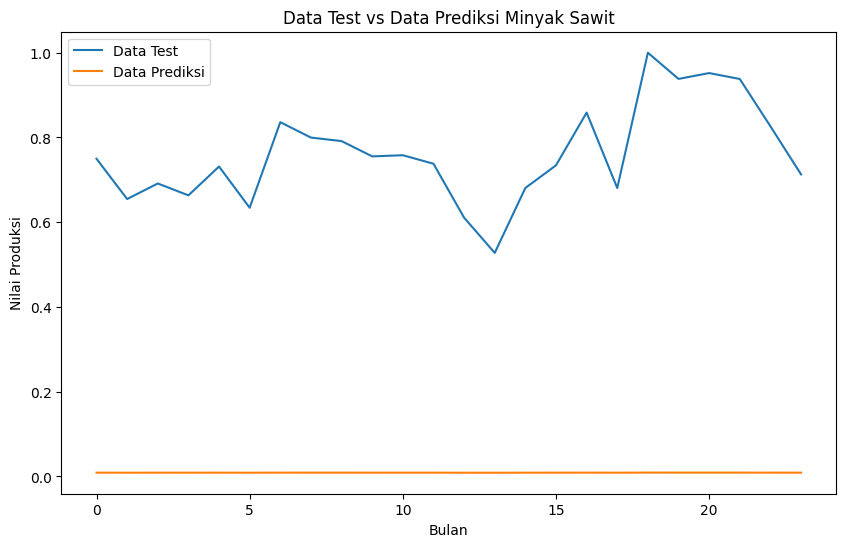

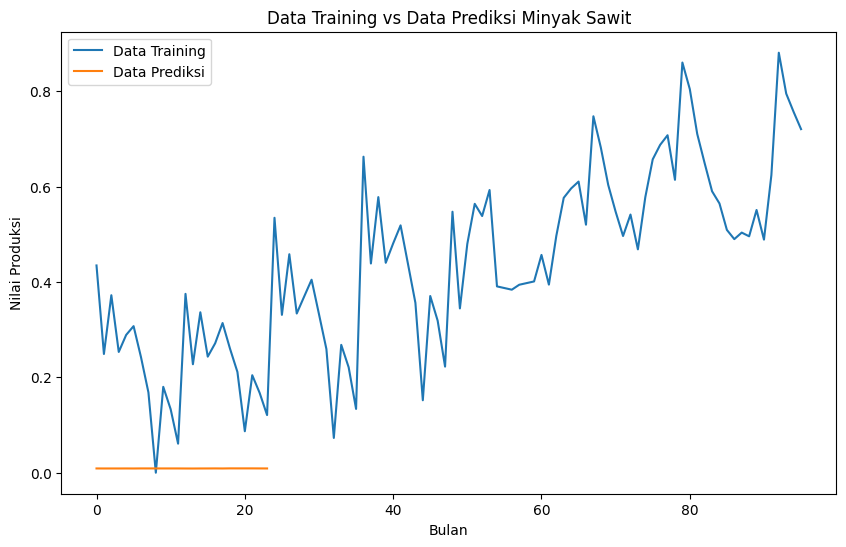

In [97]:
model_lstm(minyak_sawit, 'Minyak Sawit', 0.8, 50)

## Karet Kering

1/1 [==============================] - 2s 2s/step
Mean Absolute Error: 0.3057077899553819
R2 Score: -1.2901980160642021


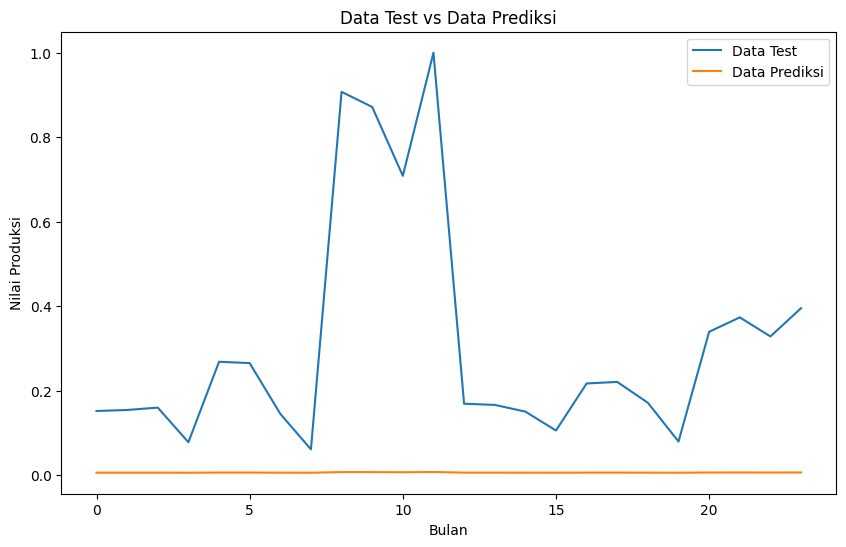

In [20]:
# model_lstm(karet_kering, 'Karet Kering')

## Teh

1/1 [==============================] - 1s 1s/step
Mean Absolute Error: 0.3670546862251191
R2 Score: -4.850340771421166


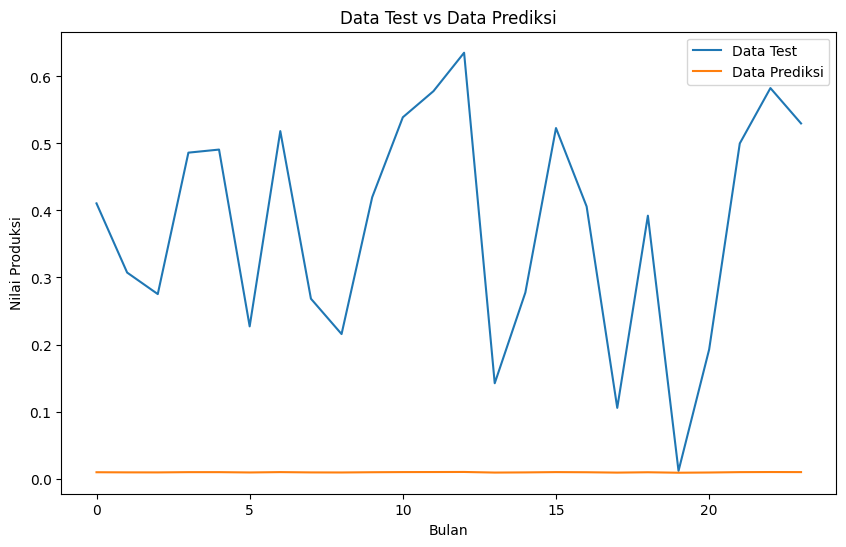

In [21]:
# model_lstm(teh, 'Teh')

# SVR Model

In [108]:
def model_svr(data, attribute_name, split_percentage=0.8, c=1.0, gamma='scale'):
  X_train, X_test = split_data(data, split_percentage)
  model = make_pipeline(MinMaxScaler(), SVR(C=c, epsilon=0.2, gamma=gamma))
  model.fit(X_train.reshape(-1,1), X_train.reshape(-1,1))
  y_pred = model.predict(scaler.transform(X_test.reshape(-1,1)))

  generate_mae_r2(X_test, y_pred)
  generate_plot(X_test, y_pred, 'Data Test', 'Data Prediksi',attribute_name)
  generate_plot(X_train, y_pred, 'Data Training', 'Data Prediksi', attribute_name)

# SVR Evaluation

## Minyak Sawit

In [109]:
model_svr(minyak_sawit, 'Minyak Sawit', 0.8, 1.0 ,'scale')

/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.9/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


ValueError: ignored

## Karet Kering

/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mean Absolute Error: 0.16109379801603033
R2 Score: 0.6212704434559517


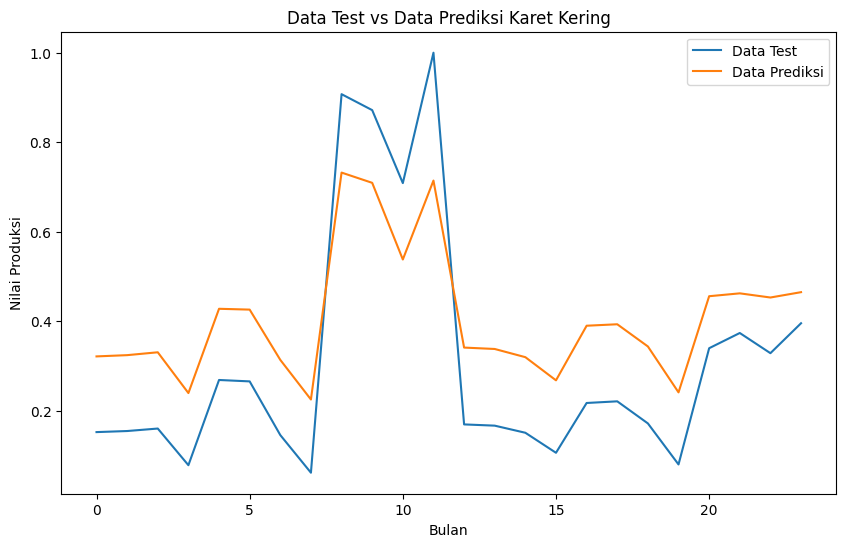

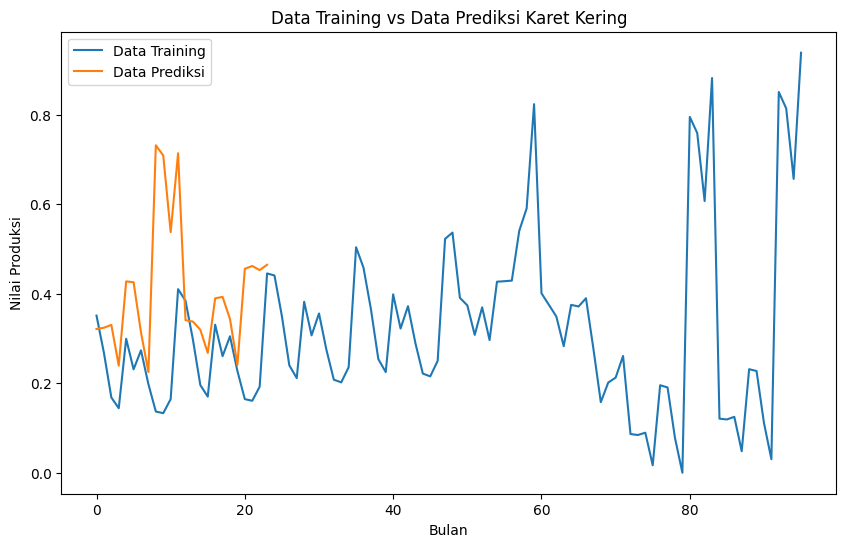

In [74]:
model_svr(karet_kering, 'Karet Kering', 0.8, 1.0 ,'scale')

## Teh

/usr/local/lib/python3.9/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mean Absolute Error: 0.10272408950193308
R2 Score: 0.46372840227147194


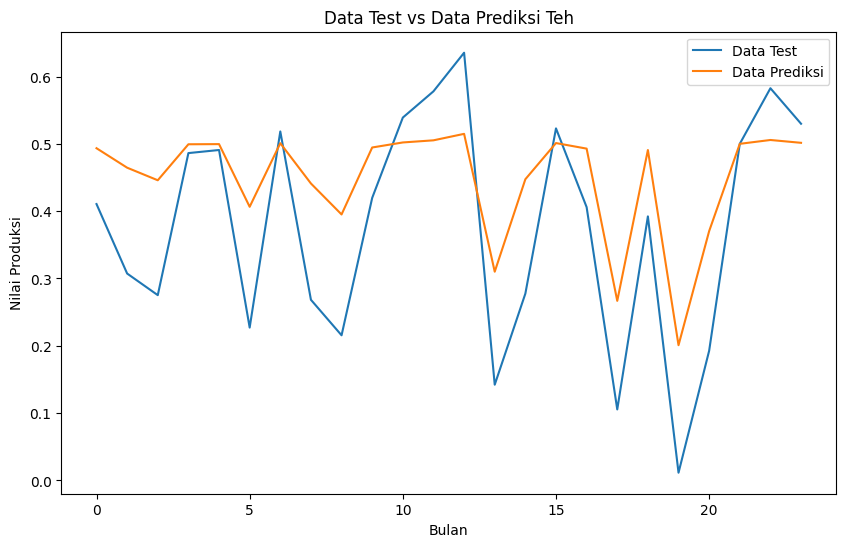

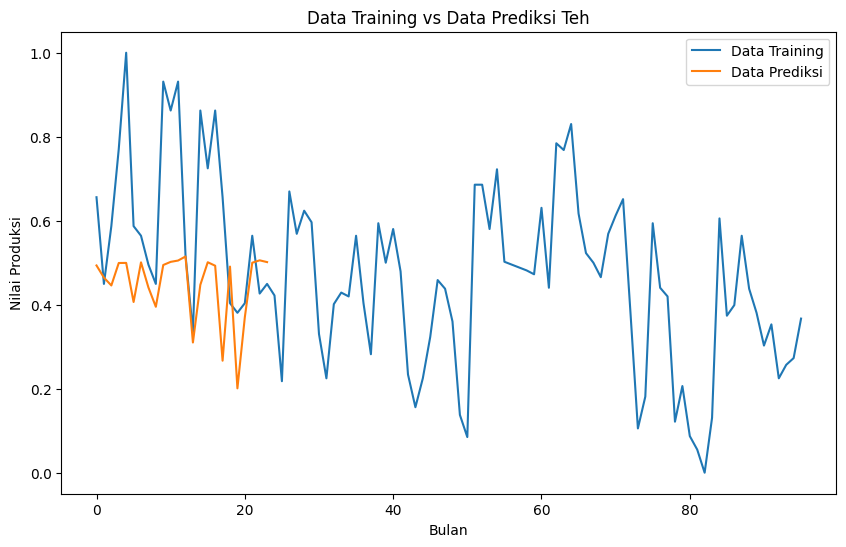

In [75]:
model_svr(teh, 'Teh', 0.8, 1.0 ,'scale')